# 선형 회귀 한번 더
이전에는 선형 회귀를 한번더 작업해보려 합니다. 

In [47]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

mpg = fetch_ucirepo(id=9)

df = pd.concat((
    mpg.data.features,
    mpg.data.targets
), axis=1)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   horsepower    392 non-null    float64
 3   weight        398 non-null    int64  
 4   acceleration  398 non-null    float64
 5   model_year    398 non-null    int64  
 6   origin        398 non-null    int64  
 7   mpg           398 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 25.0 KB
None


In [48]:
# 결측치 제거 
df = df.dropna(axis=0)
df.isna().sum()

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

In [52]:
df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,194.411990,5.471939,104.469388,2977.584184,15.541327,75.979592,1.576531,23.445918
std,104.644004,1.705783,38.491160,849.402560,2.758864,3.683737,0.805518,7.805007
min,68.000000,3.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,9.000000
25%,105.000000,4.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,17.000000
50%,151.000000,4.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,22.750000
75%,275.750000,8.000000,126.000000,3614.750000,17.025000,79.000000,2.000000,29.000000
max,455.000000,8.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,46.600000


In [56]:
numeric_values = df.drop(columns=["origin", "model_year"])
q1 = numeric_values.quantile(0.25) # Series
q3 = numeric_values.quantile(0.75) # Series
iqr = q3 - q1 # Series

high = q3 + 1.5 * iqr

low = q1 - 1.5 * iqr

# iqr_outlier = pd.concat((
#     high,
#     low
# ), axis=1).T.rename(index={0: "upper", 1: "lower"})

iqr_clean_df = df[(low < df[["displacement", "cylinders", "horsepower", "weight", "acceleration", "mpg"]])
                  & (df[["displacement", "cylinders", "horsepower", "weight", "acceleration", "mpg"]] < high)]

iqr_clean_df[["model_year", "origin"]] = df[["model_year", "origin"]]

iqr_clean_df = iqr_clean_df.dropna(axis=0)
iqr_clean_df.describe()


,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000,372.000000
mean,188.939516,5.411290,101.879032,2944.045699,15.546237,76.110215,1.594086,23.652688
std,98.717407,1.672734,33.661689,829.283502,2.402304,3.628459,0.817113,7.632497
min,68.000000,3.000000,46.000000,1613.000000,9.500000,70.000000,1.000000,9.000000
25%,105.000000,4.000000,75.750000,2220.000000,14.000000,73.000000,1.000000,17.600000
50%,146.000000,4.000000,92.000000,2764.500000,15.500000,76.000000,1.000000,23.000000
75%,258.000000,6.000000,120.000000,3542.000000,17.000000,79.000000,2.000000,29.125000
max,429.000000,8.000000,200.000000,5140.000000,21.800000,82.000000,3.000000,46.600000


## df.describe()
(내림 기준)
| 속성 | 평균 | 분산 | 
|:---:|:---:|:---:|
| 배기량 (입방인치) | 188 | 98.7 |
| 실린더 (개) | 5.4 | 1.67 |
| 무게 (파운드) | 2944 | 829 |
| 초기 도달 속도 (초) | 15.5 | 2.4 |
| 연비 (갤런/마일) | 23.6 | 7.6 |

In [57]:
iqr_clean_df.info()

<class 'pandas.DataFrame'>
Index: 372 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  372 non-null    float64
 1   cylinders     372 non-null    int64  
 2   horsepower    372 non-null    float64
 3   weight        372 non-null    int64  
 4   acceleration  372 non-null    float64
 5   model_year    372 non-null    int64  
 6   origin        372 non-null    int64  
 7   mpg           372 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 26.2 KB


In [64]:
# 표준화
from sklearn.preprocessing import StandardScaler
import numpy as np

scaler = StandardScaler()

scaled_iqr_clean_df = pd.DataFrame(scaler.fit_transform(iqr_clean_df), columns=iqr_clean_df.columns)
scaled_iqr_clean_df.describe()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
count,3.720000e+02,3.720000e+02,3.720000e+02,3.720000e+02,3.720000e+02,3.720000e+02,3.720000e+02,3.720000e+02
mean,3.820122e-17,1.146037e-16,9.550306e-17,-2.292073e-16,4.966159e-16,3.056098e-16,5.730183e-17,3.820122e-17
std,1.001347e+00,1.001347e+00,1.001347e+00,1.001347e+00,1.001347e+00,1.001347e+00,1.001347e+00,1.001347e+00
min,-1.226758e+00,-1.443468e+00,-1.662254e+00,-1.607217e+00,-2.520239e+00,-1.686238e+00,-7.280340e-01,-1.922362e+00
25%,-8.514463e-01,-8.448390e-01,-7.772701e-01,-8.742738e-01,-6.445142e-01,-8.583268e-01,-7.280340e-01,-7.940835e-01
50%,-4.355599e-01,-8.448390e-01,-2.938753e-01,-2.167986e-01,-1.927268e-02,-3.041607e-02,-7.280340e-01,-8.562954e-02
75%,7.005198e-01,3.524186e-01,5.390512e-01,7.220204e-01,6.059689e-01,7.974946e-01,4.974350e-01,7.179409e-01
max,2.435070e+00,1.549676e+00,2.918841e+00,2.651580e+00,2.606742e+00,1.625405e+00,1.722904e+00,3.010577e+00


In [65]:
scaled_iqr_clean_df.corr()

,displacement,cylinders,horsepower,weight,acceleration,model_year,origin,mpg
displacement,1.000000,0.955883,0.888231,0.940350,-0.489523,-0.315537,-0.622121,-0.807124
cylinders,0.955883,1.000000,0.857902,0.898313,-0.474818,-0.305033,-0.561826,-0.773752
horsepower,0.888231,0.857902,1.000000,0.882085,-0.652216,-0.354527,-0.464135,-0.791483
weight,0.940350,0.898313,0.882085,1.000000,-0.382518,-0.268218,-0.586258,-0.832137
acceleration,-0.489523,-0.474818,-0.652216,-0.382518,1.000000,0.225736,0.196334,0.375479
model_year,-0.315537,-0.305033,-0.354527,-0.268218,0.225736,1.000000,0.156953,0.552155
origin,-0.622121,-0.561826,-0.464135,-0.586258,0.196334,0.156953,1.000000,0.563733
mpg,-0.807124,-0.773752,-0.791483,-0.832137,0.375479,0.552155,0.563733,1.000000


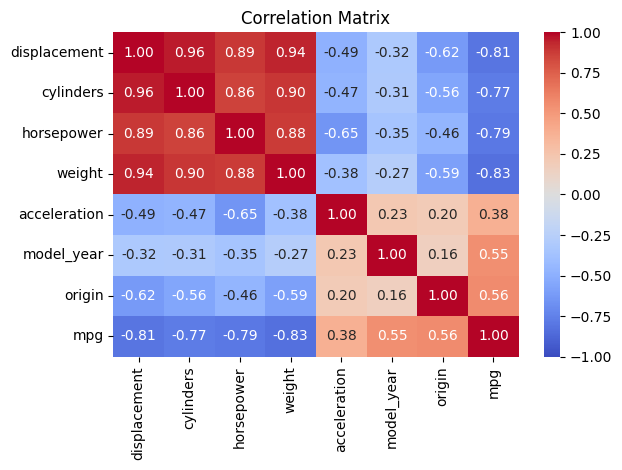

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    scaled_iqr_clean_df.corr(),
    annot=True, # 각 칸에 숫자 표시
    fmt=".2f", # 소수점 포멧
    cmap="coolwarm", # 색깔
    vmin=-1, # 색상 범위 최솟값
    vmax=1, # 색상 범위 최댓값
    center=0 # 값 0을 색상표의 중앙으로 설정
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()